In [1]:
import pandas as pd
import numpy as n
import seaborn as sns
from sklearn.impute import SimpleImputer
# fillna(): replaces na with mean mode or median from single column at a time.
# SimpleImputer will replace na from multiple columns at a time
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
# We have seen OHE: for x variables, Lable Encoding: for y variable
# OrdinalEncoder: works same as Lable Encoder but on x variables
#from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
import warnings
warnings.filterwarnings('ignore')

In [2]:
cars=pd.read_csv("ToyotaCorolla - MLR.csv")
cars

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [3]:
cars.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [4]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
cars.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

There are no Null values in dataset


In [6]:
cars.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1431    False
1432    False
1433    False
1434    False
1435    False
Length: 1436, dtype: bool

In [7]:
cars[cars.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


These is the duplicate row in dataset. So we have to drop these row.


In [8]:
cars.drop_duplicates(ignore_index=True)

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1430,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1431,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1432,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1433,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


their are now 1435 X 11 but previously we are having 1436 X 11 because we dropped one row i.e. duplicated row

In [9]:
Numeric=cars.select_dtypes(include=['int']).columns
Numeric

Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight'],
      dtype='object')

<Axes: >

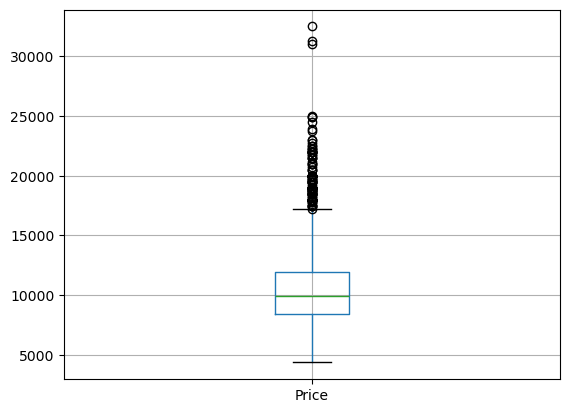

In [10]:
cars.boxplot('Price')

In [11]:
cars.select_dtypes(include=['int']).corr()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876590,-0.569960,0.314990,0.033081,0.126389,0.185326,NaN,0.063104,0.581198
Age_08_04,-0.876590,1.000000,0.505672,-0.156622,0.031717,-0.098084,-0.148359,NaN,-0.005364,-0.470253
KM,-0.569960,0.505672,1.000000,-0.333538,-0.081854,0.102683,-0.036197,NaN,0.015023,-0.028598
HP,0.314990,-0.156622,-0.333538,1.000000,0.013144,0.035856,0.092424,NaN,0.209477,0.089614
Automatic,0.033081,0.031717,-0.081854,0.013144,1.000000,0.066740,-0.027654,NaN,-0.098555,0.057249
cc,0.126389,-0.098084,0.102683,0.035856,0.066740,1.000000,0.079903,NaN,0.014629,0.335637
Doors,0.185326,-0.148359,-0.036197,0.092424,-0.027654,0.079903,1.000000,NaN,-0.160141,0.302618
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063104,-0.005364,0.015023,0.209477,-0.098555,0.014629,-0.160141,NaN,1.000000,0.020613
Weight,0.581198,-0.470253,-0.028598,0.089614,0.057249,0.335637,0.302618,NaN,0.020613,1.000000


In [12]:
cars[['Price','Weight']].corr()

,Price,Weight
Price,1.000000,0.581198
Weight,0.581198,1.000000


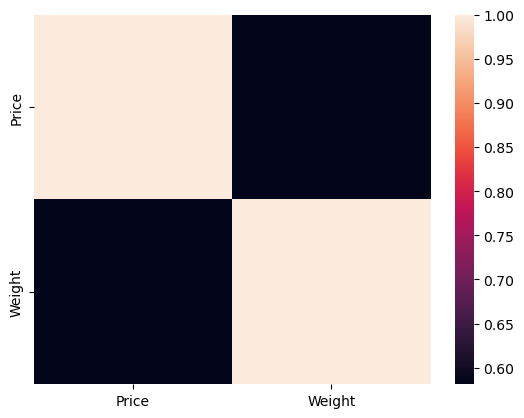

In [13]:
sns.heatmap(cars[['Price','Weight']].corr())
plt.show()

There is one categorical column Fuel_Type so we have to convert in numerical

In [14]:
oe = OrdinalEncoder() # convert categorical values to numerical
cars['Fuel_Type'] = oe.fit_transform(cars[['Fuel_Type']]).astype(int)

In [15]:
cars

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,86,0,1300,3,4,5,1025
1432,10845,72,19000,2,86,0,1300,3,4,5,1015
1433,8500,71,17016,2,86,0,1300,3,4,5,1015
1434,7250,70,16916,2,86,0,1300,3,4,5,1015


In [16]:
cars.dtypes

Price        int64
Age_08_04    int64
KM           int64
Fuel_Type    int32
HP           int64
Automatic    int64
cc           int64
Doors        int64
Cylinders    int64
Gears        int64
Weight       int64
dtype: object

**Model** **Building**

In [17]:
x= cars.drop('Price', axis=1)
y= cars['Price']

In [18]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

In [19]:
print(xtrain.shape)
print(ytrain.shape)
print(xtest.shape)
print(ytest.shape)

(1148, 10)
(1148,)
(288, 10)
(288,)


In [20]:
# Linear Regression Model
lr = LinearRegression()
lr.fit(xtrain,ytrain)
ypred = lr.predict(xtest)
ypred

array([11176.88365168,  8969.1938439 ,  9390.64915234,  8959.94241825,
       10094.01821299,  7913.49724682,  8711.31021617,  8272.4299364 ,
       14099.45852336, 13127.72764197,  9501.54591049,  9334.42692059,
       12951.90705321, 12972.83756342,  9790.64330039,  8265.25917943,
       12224.51772432, 17544.47058521,  7438.66374444,  9163.16957768,
       12709.45670685, 17800.43098183,  7897.53078219, 10411.70134794,
        7510.34559491, 16023.02765902, 10009.09251399,  7384.1061756 ,
       15660.75614251, 14492.87243282,  8163.60889331,  9721.89850261,
        8517.21387413, 10117.4453602 , 10270.74638079,  8061.1526819 ,
        8826.78990137,  9983.54452121, 16369.15247944,  9602.28333034,
        9855.55511678,  9524.19414468,  7887.04214664,  5591.09915884,
        6813.79842794, 17188.49868866,  9454.68153269, 10708.19290246,
        8717.9298301 , 13466.54920006, 12986.62729073,  6339.25682125,
       14945.71922901, 16286.20925466,  6104.08639256,  7772.71794599,
      

to calculate the test and train values R-square, intercept value and relationo between the target variable and each feature.

In [21]:
lr.intercept_ # y intercept i.e. c value

-12636.278112384865

In [22]:
lr.coef_ # slope or coefficient or weight

array([-1.21436240e+02, -1.69355966e-02,  8.62056431e+02,  2.06582831e+01,
        2.45196891e+02, -7.35153881e-02, -3.62796477e+01,  1.02318154e-12,
        5.30282040e+02,  2.35106426e+01])

In [23]:
lr.score(xtrain,ytrain),lr.score(xtest,ytest) # Train accuracy, Test accuracy
# overfitted model as high train accuracy and low test accuracy

(0.8695032279244472, 0.8428476112017994)

In [24]:
from sklearn.metrics import r2_score

In [25]:
r2_score(ytest,ypred)

0.8428476112017994

In [26]:
sns.regplot(data=cars,x=ytest,y=ypred,scatter_kws={'color':'green'},line_kws={'color':'red'})

<Axes: xlabel='Price'>

By using statsmodel

In [27]:
import statsmodels.formula.api as smf
model1 = smf.ols('Price~Age_08_04+KM+HP+cc+Doors+Gears+Weight+Fuel_Type',data=cars).fit()

In [28]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     1139.
Date:                Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                        16:41:25   Log-Likelihood:                -12371.
No. Observations:                1436   AIC:                         2.476e+04
Df Residuals:                    1427   BIC:                         2.481e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9979.8423   1478.436     -6.750      0.000   -1.29e+04   -7079.700
Age_08_04   -123.1503      2.610    -47.182      0.000    -128.270    -118.030
KM            -0.0178      0.001    -13.560      0.000      -0.020      -0.015
HP            23.3776      2.873      8.136      0.000      17.741      29.014
cc            -0.0443      0.090     -0.493      0.622      -0.220       0.132
Doors        -36.5649     40.251     -0.908      0.364    -115.523      42.393
Gears        579.4974    196.527      2.949      0.003     193.984     965.011
Weight        21.0801      1.011     20.848      0.000      19.097      23.064
Fuel_Type    610.8583    145.664      4.194      0.000     325.119     896.598
==============================================================================
Omnibus:                      276.992   Durbin-Watson:                   1.607
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2954.484
Skew:                          -0.568   Prob(JB):                         0.00
Kurtosis:                       9.935   Cond. No.                     3.28e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.28e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [29]:
model2 = smf.ols('Price~cc',data=cars).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     23.28
Date:                Mon, 14 Jul 2025   Prob (F-statistic):           1.55e-06
Time:                        16:41:26   Log-Likelihood:                -13795.
No. Observations:                1436   AIC:                         2.759e+04
Df Residuals:                    1434   BIC:                         2.760e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   9027.5548    365.576     24.694      0.000    8310.435    9744.675
cc             1.0802      0.224      4.825      0.000       0.641       1.519
==============================================================================
Omnibus:                      465.181   Durbin-Watson:                   0.267
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1390.401
Skew:                           1.649   Prob(JB):                    1.20e-302
Kurtosis:                       6.516   Cond. No.                     6.29e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.29e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
model3 = smf.ols('Price~Doors',data=cars).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     51.00
Date:                Mon, 14 Jul 2025   Prob (F-statistic):           1.46e-12
Time:                        16:41:27   Log-Likelihood:                -13782.
No. Observations:                1436   AIC:                         2.757e+04
Df Residuals:                    1434   BIC:                         2.758e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7885.0058    409.438     19.258      0.000    7081.843    8688.168
Doors        705.5586     98.795      7.142      0.000     511.761     899.356
==============================================================================
Omnibus:                      466.779   Durbin-Watson:                   0.287
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1406.209
Skew:                           1.651   Prob(JB):                    4.42e-306
Kurtosis:                       6.549   Cond. No.                         19.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
model4 = smf.ols('Price~Doors+cc',data=cars).fit()
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     35.24
Date:                Mon, 14 Jul 2025   Prob (F-statistic):           1.15e-15
Time:                        16:41:28   Log-Likelihood:                -13772.
No. Observations:                1436   AIC:                         2.755e+04
Df Residuals:                    1433   BIC:                         2.757e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6509.4211    515.773     12.621      0.000    5497.670    7521.173
Doors        671.3973     98.501      6.816      0.000     478.176     864.619
cc             0.9597      0.221      4.340      0.000       0.526       1.393
==============================================================================
Omnibus:                      448.845   Durbin-Watson:                   0.290
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1294.854
Skew:                           1.603   Prob(JB):                    6.70e-282
Kurtosis:                       6.370   Cond. No.                     9.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [32]:
model5 = smf.ols('Price~Age_08_04+KM+HP+cc+Doors', data=cars).fit()
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     1266.
Date:                Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                        16:41:28   Log-Likelihood:                -12592.
No. Observations:                1436   AIC:                         2.520e+04
Df Residuals:                    1430   BIC:                         2.523e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.508e+04    406.994     37.055      0.000    1.43e+04    1.59e+04
Age_08_04   -150.7765      2.633    -57.259      0.000    -155.942    -145.611
KM            -0.0131      0.001     -9.627      0.000      -0.016      -0.010
HP            34.4423      2.935     11.736      0.000      28.685      40.199
cc             0.4744      0.099      4.769      0.000       0.279       0.670
Doors        183.2118     43.977      4.166      0.000      96.946     269.477
==============================================================================
Omnibus:                      395.536   Durbin-Watson:                   1.342
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2880.102
Skew:                           1.082   Prob(JB):                         0.00
Kurtosis:                       9.592   Cond. No.                     7.73e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.73e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [33]:
model5.resid.plot(kind='hist')

<Axes: ylabel='Frequency'>

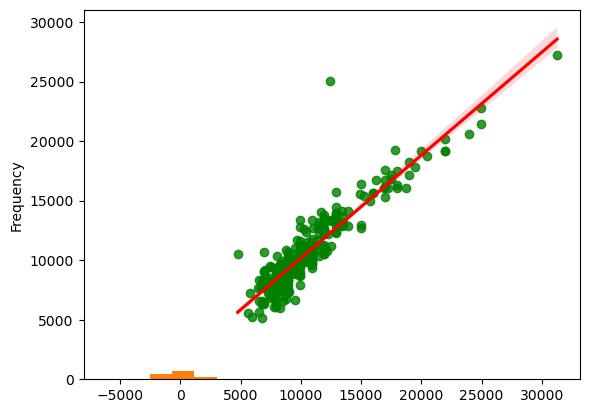

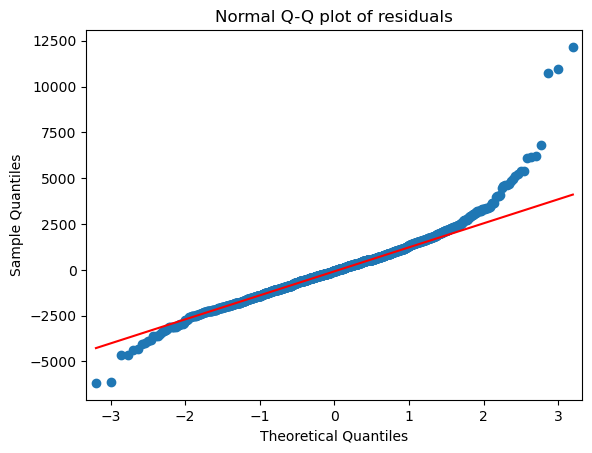

In [34]:
import statsmodels.api as smi
qqplot = smi.qqplot(model5.resid,line='q')
plt.title('Normal Q-Q plot of residuals')
plt.show()

**Lasso (L1) Regression**

In [35]:
l1 = Lasso() # alpha = 0.1 by default
l1.fit(xtrain,ytrain)
l1.score(xtrain,ytrain),l1.score(xtest,ytest)

(0.8694985278360453, 0.8429414838867533)

In [36]:
l1.coef_

array([-1.21372123e+02, -1.69928764e-02,  8.49605132e+02,  2.08317267e+01,
        2.24725572e+02, -7.32847182e-02, -3.58991409e+01,  0.00000000e+00,
        5.01974246e+02,  2.34718712e+01])

**Ridge (L2) Regression**

In [37]:
l2= Ridge()# alpha = 0.1 by default
l2.fit(xtrain,ytrain)
l2.score(xtrain,ytrain),l2.score(xtest,ytest)

(0.8695021567791127, 0.8429634282301911)

In [38]:
l2.coef_

array([-1.21416308e+02, -1.69724308e-02,  8.51619534e+02,  2.07801481e+01,
        2.41303341e+02, -7.38416938e-02, -3.63199959e+01,  0.00000000e+00,
        5.18174870e+02,  2.34721914e+01])

**Questions Asked**

Q1)Normalization: it scales numerical fetaures to a range between 0 and 1. Helps when algorithms are sensitive to the scale of input features like K-Nearest Neighbors or Neural Networks.

Standardization: it transforms data to have a mean of 0 and SD of 1.helps with the algorithms that assume data is normally distributed, like Linear Regression and Logistic Regression.

Q2)Some we can use to address multi-collinearity in muliplr linear regression are: feature removal ; Feature combination ; regularization ; pca ; variance inflation factor.